# DBSCAN & HDBSCAN: Density-Based Clustering for Complex Data

**Tagline:** Find clusters of any shape, in any density — without telling the algorithm how many to look for.

## Learning Objectives

After completing this notebook, you will:
- Understand the core concepts of density-based clustering and why it differs from centroid-based methods
- Implement DBSCAN from scratch using NumPy, including core/border/noise point logic
- Master Scikit-Learn's DBSCAN implementation and the advanced HDBSCAN algorithm
- Interpret parameters (eps, min_samples for DBSCAN; min_cluster_size for HDBSCAN)
- Handle clusters of varying densities using HDBSCAN's hierarchical approach
- Evaluate cluster quality using Silhouette Score, Davies-Bouldin Index, and domain-specific metrics
- Distinguish when to use DBSCAN vs. HDBSCAN vs. K-Means based on data characteristics
- Answer FAANG-style interview questions about density-based clustering with confidence

## Prerequisites

- Python 3.8+
- Understanding of: distance metrics (Euclidean), clustering fundamentals, basic graph theory (BFS/DFS)
- Familiarity with: NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn

## Dataset

**Real-world Dataset:** Mall Customers Segmentation Dataset

- **Source:** [Kaggle - Mall Customer Segmentation Data](https://www.kaggle.com/datasets/vjcspy/customer-segmentation-clustering-mall)
- **Description:** 200 customer records from a shopping mall with annual income and spending score
- **Features:** Age, Annual Income (K$), Spending Score (1-100)
- **Size:** 200 samples, 3 features
- **Why suitable:** Small dataset ideal for from-scratch implementation and visualization; non-uniform customer distribution naturally exhibits clustering at varying densities
- **Scenario:** Identify customer groups for targeted marketing; customers with similar spending patterns and incomes form natural, non-spherical clusters

## Credits & References

- Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise*
- Campello, R. J., Moulavi, D., & Sander, J. (2013). *Density-Based Clustering Based on Hierarchical Density Estimates*
- [Scikit-Learn DBSCAN Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)
- [HDBSCAN Library Documentation](https://hdbscan.readthedocs.io/en/latest/)
- StatQuest with Josh Starmer - DBSCAN Video Tutorial

In [1]:
# ============================================================================
# IMPORT ALL REQUIRED LIBRARIES
# ============================================================================

# Install HDBSCAN if not already installed
import subprocess
import sys

try:
    import hdbscan
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "hdbscan", "-q"])

# Core numerical computing and matrix operations
import numpy as np

# Data manipulation and loading CSV files
import pandas as pd

# Scikit-Learn: DBSCAN and preprocessing utilities
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clustering evaluation metrics (no ground truth available)
from sklearn.metrics import (
    silhouette_score,           # Cohesion vs separation: higher is better
    davies_bouldin_score,       # Average cluster similarity: lower is better
    calinski_harabasz_score,    # Between/within variance ratio: higher is better
)

# HDBSCAN: Hierarchical density-based clustering
import hdbscan

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.patches import Patch

# Utilities
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-Learn: {__import__('sklearn').__version__}")
try:
    print(f"HDBSCAN: {hdbscan.__version__}")
except AttributeError:
    print("HDBSCAN: version info not available (package installed successfully)")

✓ All libraries imported successfully!
NumPy: 2.4.6
Pandas: 3.0.3
Scikit-Learn: 1.9.0
HDBSCAN: version info not available (package installed successfully)


## Part 1: Theory Recap — Density-Based Clustering

### Core Concepts

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points based on local density instead of distance to centroids. A cluster is a dense region of the feature space separated from other dense regions by sparse space (noise).

**Key Definitions:**
- **Core Point:** A point with at least MinPts neighbors within distance ε (including itself)
- **Border Point:** A non-core point within ε distance of a core point
- **Noise Point:** A point that is neither core nor border
- **ε (eps):** The radius of the neighborhood search (epsilon)
- **MinPts:** Minimum number of neighbors required to form a core point

**HDBSCAN** (Hierarchical DBSCAN) extends DBSCAN by building a hierarchy of clusterings across all possible density levels, automatically selecting the most "stable" clusters. It handles varying cluster densities without requiring a global ε parameter.

### Key Intuition

Imagine a satellite view of cities at night. **DBSCAN's approach:** Define a search radius (ε) and minimum brightness threshold (MinPts). Find bright pixels (core points), connect nearby brightness to form cities (clusters), and leave dark areas (noise) unlabeled. **The limitation:** A downtown (very dense) looks like noise if ε is too small, while a suburb (sparse) gets mixed with noise if ε is too large.

**HDBSCAN's improvement:** Instead of one radius, examine all possible radii simultaneously. Find clusters that remain "stable" across a range of densities. This naturally captures both dense downtowns and sparse suburbs without parameter tuning.

### Important Mathematical Ideas

**ε-Neighborhood Definition:**
- All points q where distance(p, q) ≤ ε
- This is the geometric core of density-based clustering
- Computational bottleneck: finding these neighbors efficiently (KD-tree helps)

**Density Reachability (HDBSCAN):**
- Mutual reachability distance accounts for local density variations
- Dense regions get smaller effective distances; sparse regions larger
- Enables automatic adaptation to multi-scale cluster structures

**Cluster Stability (HDBSCAN):**
- Clusters that persist across many density thresholds are "stable"
- Stability is computed as sum of lifetime across all density levels
- Most stable clusters are selected for final output

### Five Key Bullet Points

1. **No k Parameter Required:** DBSCAN and HDBSCAN discover clusters without pre-specifying the number—clusters emerge from density. This differs fundamentally from K-Means (centroid-based) where k must be chosen.

2. **Built-In Noise Detection:** Points labeled -1 are natural outliers/anomalies. This is crucial for exploratory analysis on real-world data where some observations don't fit any cluster.

3. **Arbitrary Cluster Shapes:** Unlike K-Means (assumes spheres), density-based methods discover crescents, rings, blobs, and irregular shapes. Perfect for complex, non-convex cluster structures.

4. **DBSCAN Struggles with Varying Densities:** A single ε works poorly when clusters have different internal densities. HDBSCAN solves this through hierarchical density adaptation.

5. **Interview Concept:** Density-based clustering demonstrates understanding of graph connectivity, neighborhood queries, BFS/DFS traversal, and the curse of dimensionality. Explaining why ε becomes meaningless in high dimensions (all distances converge) signals deep algorithmic thinking.

---

## Section 1: Loading and Exploring the Real-World Dataset

### Why This Step Matters

Before clustering, we must understand our data's structure, feature distributions, and potential challenges. The Mall Customers dataset is ideal for density-based clustering because:
- **Small size (~200 samples):** Manageable for from-scratch implementation and visualization
- **Low dimensionality (3 features):** Can be visualized in 2D/3D
- **Real patterns:** Customer groups naturally exhibit varying densities (some tight groups, some sparse outliers)
- **Business relevance:** Clustering reveals customer segments for targeted marketing strategies

This notebook treats the dataset unsupervised—we don't use any ground-truth labels, making it realistic for exploratory data analysis (EDA) scenarios where the true cluster structure is unknown.

In [2]:
# ============================================================================
# LOAD AND EXPLORE THE MALL CUSTOMERS DATASET
# ============================================================================

# Load the dataset from Kaggle (Mall Customers Segmentation)
# If not available locally, download from: https://www.kaggle.com/datasets/vjcspy/customer-segmentation-clustering-mall

# Try to load from local path first
import os

local_paths = [
    '../04-kmeans/Mall_Customers.csv',  # Relative to 06-dbscan-hdbscan folder
    './Mall_Customers.csv',              # Current folder
    '../Mall_Customers.csv',             # Parent folder
]

df = None
for path in local_paths:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✓ Loaded from: {path}")
        break

if df is None:
    # If not found locally, create it from Kaggle dataset or use sklearn dataset as fallback
    print("Dataset not found locally. Using customer data from sklearn + synthetic income/spending...")
    # Create a realistic mall customer dataset programmatically
    np.random.seed(42)
    n_samples = 200
    
    # Age: realistic customer ages
    age = np.random.normal(loc=40, scale=15, size=n_samples)
    age = np.clip(age, 18, 80).astype(int)
    
    # Annual Income (K$): reasonable range for mall customers
    income = np.random.normal(loc=60, scale=30, size=n_samples)
    income = np.clip(income, 15, 137)
    
    # Spending Score (1-100): customer spending habits
    spending_score = np.random.normal(loc=50, scale=25, size=n_samples)
    spending_score = np.clip(spending_score, 1, 100).astype(int)
    
    df = pd.DataFrame({
        'CustomerID': np.arange(1, n_samples + 1),
        'Age': age,
        'Annual Income (k$)': income,
        'Spending Score (1-100)': spending_score
    })

print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {df.shape} (200 samples, 4 columns)")
print(f"\nFirst 10 rows:")
print(df.head(10))

print("\n" + "=" * 70)
print("DATA TYPE INFORMATION")
print("=" * 70)
print(df.info())

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)
print(df.describe())

print("\n" + "=" * 70)
print("MISSING VALUES CHECK")
print("=" * 70)
print(f"Total missing values: {df.isnull().sum().sum()}")
print("✓ No missing values detected!")

print("\n" + "=" * 70)
print("FEATURE ANALYSIS")
print("=" * 70)

# Analyze features used for clustering (exclude CustomerID)
clustering_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for feature in clustering_features:
    col_data = df[feature]
    print(f"\n{feature}:")
    print(f"  Range: [{col_data.min():.2f}, {col_data.max():.2f}]")
    print(f"  Mean: {col_data.mean():.2f}, Std: {col_data.std():.2f}")
    print(f"  Skewness: {col_data.skew():.3f}")

print("\n✓ Why density-based clustering is suitable:")
print("  1. Real-world customer groups often have non-convex shapes")
print("  2. Natural variations in group density (tight inner circle vs. outliers)")
print("  3. No pre-specified number of customer segments")
print("  4. Automatic outlier/anomaly detection for high-value unusual customers")

✓ Loaded from: ../04-kmeans/Mall_Customers.csv
DATASET OVERVIEW

Shape: (200, 5) (200 samples, 4 columns)

First 10 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
5           6  Female   22                  17                      76
6           7  Female   35                  18                       6
7           8  Female   23                  18                      94
8           9    Male   64                  19                       3
9          10  Female   30                  19                      72

DATA TYPE INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns 

---

## Section 2: Data Preprocessing and Feature Scaling

### Why Preprocessing is Critical for Density-Based Clustering

Density-based methods use distance metrics (Euclidean) to define neighborhoods (ε-neighborhoods). If features have different scales:
- A feature with range [0, 100] dominates one with range [0, 1]
- The ε parameter becomes meaningless—it's defined in the coordinate system
- Neighborhoods become biased toward high-scale features

**StandardScaler Normalization:** Transforms all features to mean=0, std=1. Now all features contribute equally to distance calculations.

**Outlier Handling:** Unlike K-Means (which assigns outliers to nearest centroid), density-based methods can naturally mark extreme points as noise (label = -1). We inspect outliers but keep them for realistic evaluation.

In [3]:
# ============================================================================
# DATA PREPROCESSING AND FEATURE SCALING
# ============================================================================

print("=" * 70)
print("PREPROCESSING PIPELINE")
print("=" * 70)

# Step 1: Extract only features used for clustering (drop CustomerID)
clustering_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[clustering_features].values

print(f"\n1. Extracted features: shape = {X.shape}")
print(f"   Features: {clustering_features}")

# Step 2: Check for missing values
missing_count = np.sum(np.isnan(X))
print(f"\n2. Missing value check:")
print(f"   Missing values: {missing_count}")
if missing_count == 0:
    print("   ✓ No missing values — dataset is clean")

# Step 3: Outlier inspection using z-scores
from scipy import stats
z_scores = np.abs(stats.zscore(X))
outlier_threshold = 3

outliers_detected = np.where((z_scores > outlier_threshold).any(axis=1))[0]
print(f"\n3. Outlier detection (z-score threshold = {outlier_threshold}):")
print(f"   Outliers found: {len(outliers_detected)} out of {len(X)} samples ({100*len(outliers_detected)/len(X):.1f}%)")
if len(outliers_detected) > 0:
    print(f"   Indices: {outliers_detected}")
    print("   Decision: Keep outliers (density-based methods naturally identify as noise)")
else:
    print("   ✓ No extreme outliers detected")

# Step 4: CRITICAL — Feature scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n4. Feature scaling (StandardScaler):")
print(f"\n   BEFORE scaling:")
print(f"   Example first row: {X[0]}")
for i, feature in enumerate(clustering_features):
    print(f"      {feature}: range [{X[:, i].min():.2f}, {X[:, i].max():.2f}]")

print(f"\n   AFTER scaling:")
print(f"   Example first row: {X_scaled[0]}")
for i, feature in enumerate(clustering_features):
    print(f"      {feature}: range [{X_scaled[:, i].min():.2f}, {X_scaled[:, i].max():.2f}]")

print(f"\n   Verification:")
print(f"   Mean of scaled features: {X_scaled.mean(axis=0)}")
print(f"   Std of scaled features: {X_scaled.std(axis=0)}")
print("   ✓ All features are now standardized (mean≈0, std≈1)")

# Store preprocessed data
X_processed = X_scaled
print(f"\n5. Final preprocessed data:")
print(f"   Shape: {X_processed.shape}")
print(f"   Data type: {X_processed.dtype}")

print(f"\n{'=' * 70}")
print("✓ Preprocessing complete!")

PREPROCESSING PIPELINE

1. Extracted features: shape = (200, 3)
   Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

2. Missing value check:
   Missing values: 0
   ✓ No missing values — dataset is clean

3. Outlier detection (z-score threshold = 3):
   Outliers found: 0 out of 200 samples (0.0%)
   ✓ No extreme outliers detected

4. Feature scaling (StandardScaler):

   BEFORE scaling:
   Example first row: [19 15 39]
      Age: range [18.00, 70.00]
      Annual Income (k$): range [15.00, 137.00]
      Spending Score (1-100): range [1.00, 99.00]

   AFTER scaling:
   Example first row: [-1.42456879 -1.73899919 -0.43480148]
      Age: range [-1.50, 2.24]
      Annual Income (k$): range [-1.74, 2.92]
      Spending Score (1-100): range [-1.91, 1.89]

   Verification:
   Mean of scaled features: [-1.02140518e-16 -2.13162821e-16 -1.46549439e-16]
   Std of scaled features: [1. 1. 1.]
   ✓ All features are now standardized (mean≈0, std≈1)

5. Final preprocessed data:
   Sha

---

## Part 2: From-Scratch DBSCAN Implementation Using NumPy

### Algorithm Overview

DBSCAN discovers clusters through density-based region growing:

1. **Identify Core Points:** Points with ≥ MinPts neighbors within radius ε
2. **Build Clusters:** Start from any unvisited core point, use BFS to expand to all density-reachable core points
3. **Assign Border Points:** Non-core points within ε of a core point join that cluster
4. **Mark Noise:** Remaining unvisited points become noise (label = -1)

### Key Data Structures

- **Labels Array:** Stores cluster ID for each point (-1 for noise)
- **Visited Set:** Tracks which points have been processed
- **Cluster Counter:** Increments each time a new cluster starts

### Why Build from Scratch?

- **Interview Value:** Shows algorithmic thinking, graph traversal, and software engineering
- **Educational:** Clarifies how ε and MinPts control cluster discovery
- **Debugging:** Understanding internals helps tune hyperparameters in production
- **Production Code:** From-scratch is rarely used (too slow without KD-tree indexing), but library versions rely on these concepts

### Important Implementation Details

- **Time Complexity:** O(n²) without spatial indexing; O(n log n) with KD-tree
- **Neighbor Search:** Naive approach tests all points; optimized uses KD-tree for O(log n) range queries
- **Border Point Assignment:** First-come-first-served; if reachable from multiple clusters, assigned to the one processed first
- **Non-Determinism:** Processing order of core points can affect border point assignments (use DBSCAN* variant to eliminate this)

In [4]:
# ============================================================================
# DBSCAN FROM SCRATCH - CLASS IMPLEMENTATION
# ============================================================================

class DBSCANScratch:
    """
    DBSCAN (Density-Based Spatial Clustering) implementation from scratch using NumPy.
    
    This is a naive O(n²) implementation without spatial indexing. For production use,
    always use Scikit-Learn's optimized version with KD-tree indexing.
    
    Interview Notes:
    - Demonstrates understanding of density-based clustering concepts
    - Shows graph traversal (BFS) and neighborhood connectivity
    - O(n²) time without spatial indexing; O(n log n) with KD-tree
    - Core point, border point, noise point taxonomy
    
    Attributes:
        eps (float): Radius of neighborhood (epsilon)
        min_samples (int): Minimum neighbors to be a core point (MinPts)
        labels_ (array): Final cluster labels (-1 for noise)
        n_clusters_ (int): Number of clusters found
    """
    
    def __init__(self, eps=0.5, min_samples=5):
        """
        Initialize DBSCAN parameters.
        
        Args:
            eps: Radius threshold for ε-neighborhoods
            min_samples: Minimum neighbors (including self) for core point status
        """
        self.eps = eps
        self.min_samples = min_samples
        self.labels_ = None
        self.n_clusters_ = None
    
    def _euclidean_distance(self, p1, p2):
        """Compute Euclidean distance between two points."""
        return np.sqrt(np.sum((p1 - p2) ** 2))
    
    def _region_query(self, X, point_idx):
        """
        Find all points within eps distance of a given point.
        
        This is the core density operation: retrieve the ε-neighborhood.
        Time Complexity: O(n) naive; O(log n) with KD-tree
        
        Args:
            X: Data array (n_samples, n_features)
            point_idx: Index of query point
        
        Returns:
            List of neighbor indices (including the point itself if needed)
        """
        neighbors = []
        query_point = X[point_idx]
        
        for idx, point in enumerate(X):
            distance = self._euclidean_distance(query_point, point)
            if distance <= self.eps:
                neighbors.append(idx)
        
        return neighbors
    
    def _expand_cluster(self, X, point_idx, neighbors, labels, cluster_id):
        """
        Expand a cluster from a core point using BFS-style expansion.
        
        All density-reachable core points are added to the cluster,
        along with their border points.
        
        Args:
            X: Data array
            point_idx: Index of the core point starting this cluster
            neighbors: Initial neighbors of the core point
            labels: Current cluster labels array (modified in-place)
            cluster_id: ID for this cluster
        
        Returns:
            True if cluster expanded successfully
        """
        # Mark current point as this cluster
        labels[point_idx] = cluster_id
        
        # BFS-style expansion through core points
        seed_set = list(neighbors)  # Points to potentially expand from
        
        while seed_set:
            current_idx = seed_set.pop(0)
            
            # Skip if already assigned to a cluster
            if labels[current_idx] != -1:
                continue
            
            # Assign current point to this cluster (border or core)
            labels[current_idx] = cluster_id
            
            # If current point is also a core point, expand further
            current_neighbors = self._region_query(X, current_idx)
            if len(current_neighbors) >= self.min_samples:
                # This is a core point—add its unvisited neighbors to seed set
                for neighbor_idx in current_neighbors:
                    if labels[neighbor_idx] == -1:  # Not yet assigned
                        seed_set.append(neighbor_idx)
        
        return True
    
    def fit(self, X):
        """
        Cluster the data using DBSCAN algorithm.
        
        Algorithm:
        1. Initialize all labels to -1 (noise)
        2. For each unvisited point:
           a. Find its ε-neighborhood
           b. If core point, expand cluster from it (BFS)
           c. If border point, skip (will be assigned when core point reaches it)
           d. If noise, keep label = -1
        
        Time Complexity: O(n²) naive; O(n log n) with KD-tree
        Space Complexity: O(n)
        """
        n_samples = X.shape[0]
        
        # Initialize: all points start as noise (-1)
        labels = np.array([-1] * n_samples)
        
        cluster_id = 0
        
        print(f"[DBSCAN Scratch] Clustering with eps={self.eps}, min_samples={self.min_samples}...")
        start_time = time.time()
        
        # Iterate through all points
        for point_idx in range(n_samples):
            # Skip if already assigned
            if labels[point_idx] != -1:
                continue
            
            # Find neighbors of this point
            neighbors = self._region_query(X, point_idx)
            
            # Check if this is a core point
            if len(neighbors) < self.min_samples:
                # Not enough neighbors—stays as noise/border (label = -1 for now)
                continue
            
            # This is a CORE point—expand a new cluster from it
            self._expand_cluster(X, point_idx, neighbors, labels, cluster_id)
            cluster_id += 1
        
        # Calculate statistics
        self.labels_ = labels
        self.n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
        self.n_noise_ = np.sum(labels == -1)
        
        elapsed = time.time() - start_time
        print(f"✓ Clustering complete in {elapsed:.4f} seconds")
        print(f"  Clusters found: {self.n_clusters_}")
        print(f"  Noise points: {self.n_noise_} ({100*self.n_noise_/n_samples:.1f}%)")
        
        return self
    
    def fit_predict(self, X):
        """Fit DBSCAN and return cluster labels."""
        self.fit(X)
        return self.labels_


# Train the from-scratch implementation
print("=" * 70)
print("TRAINING SCRATCH IMPLEMENTATION")
print("=" * 70)

# Test with reasonable eps value (estimated from data scale ~3-4)
dbscan_scratch = DBSCANScratch(eps=0.8, min_samples=5)
labels_scratch = dbscan_scratch.fit_predict(X_processed)

print(f"\nCluster assignments (first 20 samples): {labels_scratch[:20]}")
print(f"Unique clusters: {sorted(set(labels_scratch))}")
print(f"Cluster sizes:")
for cluster_id in sorted(set(labels_scratch)):
    if cluster_id == -1:
        count = np.sum(labels_scratch == cluster_id)
        print(f"  Noise points: {count}")
    else:
        count = np.sum(labels_scratch == cluster_id)
        print(f"  Cluster {cluster_id}: {count} points")

print(f"\n{'=' * 70}")
print("✓ From-scratch implementation complete!")

TRAINING SCRATCH IMPLEMENTATION
[DBSCAN Scratch] Clustering with eps=0.8, min_samples=5...
✓ Clustering complete in 0.1046 seconds
  Clusters found: 1
  Noise points: 6 (3.0%)

Cluster assignments (first 20 samples): [-1  0 -1  0  0  0 -1  0  0  0  0 -1  0  0  0  0  0  0  0  0]
Unique clusters: [np.int64(-1), np.int64(0)]
Cluster sizes:
  Noise points: 6
  Cluster 0: 194 points

✓ From-scratch implementation complete!


---

## Section 3: Evaluating the Scratch Implementation

### Evaluating Unsupervised Clustering

Unlike classification (where labels are known), clustering quality is evaluated using **internal metrics** that don't require ground truth:

| Metric | Interpretation | Best Range |
|--------|---|---|
| **Silhouette Score** | -1 (poor) to 1 (excellent): measures how similar a point is to its cluster vs. other clusters | >0.5 = good |
| **Davies-Bouldin Index** | Lower is better: average ratio of within-cluster to between-cluster distances | <1.0 = good |
| **Calinski-Harabasz Index** | Higher is better: ratio of between-cluster to within-cluster variance | >100 = reasonable |

**Note:** DBSCAN noise points (label -1) complicate these metrics. We often compute them excluding noise, or use DBCV (DBSCAN Clustering Validity Index) which is noise-aware.

In [5]:
# ============================================================================
# EVALUATE SCRATCH IMPLEMENTATION
# ============================================================================

print("=" * 70)
print("SCRATCH IMPLEMENTATION EVALUATION")
print("=" * 70)

# Separate clustered points from noise for metrics computation
noise_mask = labels_scratch == -1
non_noise_mask = ~noise_mask

if np.sum(non_noise_mask) > 0 and len(set(labels_scratch[non_noise_mask])) > 1:
    # Compute metrics only for non-noise points
    X_clustered = X_processed[non_noise_mask]
    labels_clustered = labels_scratch[non_noise_mask]
    
    silhouette_scratch = silhouette_score(X_clustered, labels_clustered)
    davies_bouldin_scratch = davies_bouldin_score(X_clustered, labels_clustered)
    calinski_harabasz_scratch = calinski_harabasz_score(X_clustered, labels_clustered)
    
    print(f"\nEvaluation Metrics (excluding noise points):")
    print(f"  Silhouette Score:        {silhouette_scratch:.4f}  (Range: [-1, 1], Higher is better)")
    print(f"  Davies-Bouldin Index:    {davies_bouldin_scratch:.4f}  (Range: [0, ∞), Lower is better)")
    print(f"  Calinski-Harabasz Index: {calinski_harabasz_scratch:.4f}  (Range: [0, ∞), Higher is better)")
    
    print(f"\nInterpretation:")
    if silhouette_scratch > 0.5:
        print(f"  → Silhouette = {silhouette_scratch:.4f}: STRONG cluster structure ✓")
    elif silhouette_scratch > 0.25:
        print(f"  → Silhouette = {silhouette_scratch:.4f}: MODERATE cluster structure")
    else:
        print(f"  → Silhouette = {silhouette_scratch:.4f}: WEAK cluster structure")
    
    print(f"\nCluster Composition:")
    print(f"  Total points clustered: {np.sum(non_noise_mask)}")
    print(f"  Total noise points: {np.sum(noise_mask)} ({100*np.sum(noise_mask)/len(labels_scratch):.1f}%)")
    
    for cluster_id in sorted(set(labels_scratch[non_noise_mask])):
        count = np.sum(labels_scratch == cluster_id)
        pct = 100 * count / len(labels_scratch)
        print(f"    Cluster {cluster_id}: {count:3d} points ({pct:5.1f}%)")

else:
    print("Not enough clusters for reliable metric computation")
    silhouette_scratch = davies_bouldin_scratch = calinski_harabasz_scratch = np.nan

print(f"\n{'=' * 70}")
print("✓ Scratch implementation evaluation complete!")

SCRATCH IMPLEMENTATION EVALUATION
Not enough clusters for reliable metric computation

✓ Scratch implementation evaluation complete!


---

## Part 3: Library Implementation - Scikit-Learn DBSCAN and HDBSCAN

### Scikit-Learn's DBSCAN Optimizations

The library version uses spatial indexing (KD-tree, Ball-tree) to reduce neighbor search from O(n) to O(log n) per query, enabling O(n log n) total complexity compared to our O(n²) naive implementation.

**Key Parameters:**
- `eps`: Radius of neighborhoods
- `min_samples`: MinPts threshold
- `metric`: Distance metric (default: Euclidean)
- `algorithm`: 'auto', 'ball_tree', 'kd_tree', or 'brute' (naive)

### HDBSCAN: Hierarchical Density-Based Clustering

HDBSCAN extends DBSCAN by:
1. **Building a hierarchy across all density levels** instead of committing to one ε
2. **Computing stability scores** for each cluster—those persisting across many density thresholds are selected
3. **Handling varying cluster densities** automatically without parameter tuning
4. **Providing soft membership probabilities** and outlier scores

**Key Advantages:**
- No ε parameter needed (only `min_cluster_size`)
- Better handling of clusters with different densities
- Continuous outlier scores (not just binary)
- More robust to parameter choices

**Key Parameters:**
- `min_cluster_size`: Minimum cluster size (larger = more conservative)
- `min_samples`: Density threshold (default = `min_cluster_size`)
- `cluster_selection_method`: 'eom' (excess of mass, recommended) or 'leaf'
- `prediction_data`: Whether to store data for fast prediction on new points

In [6]:
# ============================================================================
# LIBRARY IMPLEMENTATIONS: SCIKIT-LEARN DBSCAN AND HDBSCAN
# ============================================================================

print("=" * 70)
print("SCIKIT-LEARN DBSCAN IMPLEMENTATION")
print("=" * 70)

# Train DBSCAN using scikit-learn (optimized with spatial indexing)
start_time = time.time()

dbscan_sklearn = DBSCAN(
    eps=0.8,                    # Radius of neighborhoods (same as scratch for comparison)
    min_samples=5,              # MinPts threshold
    metric='euclidean',         # Distance metric
    algorithm='ball_tree'       # Use ball-tree for faster neighbor search
)

labels_sklearn = dbscan_sklearn.fit_predict(X_processed)
elapsed_sklearn = time.time() - start_time

n_clusters_sklearn = len(set(labels_sklearn)) - (1 if -1 in labels_sklearn else 0)
n_noise_sklearn = np.sum(labels_sklearn == -1)

print(f"\nModel trained in {elapsed_sklearn:.4f} seconds")
print(f"Clusters found: {n_clusters_sklearn}")
print(f"Noise points: {n_noise_sklearn} ({100*n_noise_sklearn/len(labels_sklearn):.1f}%)")

# Compute metrics for sklearn DBSCAN
non_noise_mask_sklearn = labels_sklearn != -1
if np.sum(non_noise_mask_sklearn) > 0 and len(set(labels_sklearn[non_noise_mask_sklearn])) > 1:
    X_clustered = X_processed[non_noise_mask_sklearn]
    labels_clustered = labels_sklearn[non_noise_mask_sklearn]
    
    silhouette_sklearn = silhouette_score(X_clustered, labels_clustered)
    davies_bouldin_sklearn = davies_bouldin_score(X_clustered, labels_clustered)
    calinski_harabasz_sklearn = calinski_harabasz_score(X_clustered, labels_clustered)
    
    print(f"\nEvaluation Metrics (Scikit-Learn DBSCAN):")
    print(f"  Silhouette Score:        {silhouette_sklearn:.4f}")
    print(f"  Davies-Bouldin Index:    {davies_bouldin_sklearn:.4f}")
    print(f"  Calinski-Harabasz Index: {calinski_harabasz_sklearn:.4f}")
else:
    silhouette_sklearn = davies_bouldin_sklearn = calinski_harabasz_sklearn = np.nan

# ============================================================================
print(f"\n{'=' * 70}")
print("HDBSCAN IMPLEMENTATION")
print("=" * 70)

# Train HDBSCAN
start_time = time.time()

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,           # Minimum cluster size (conservative approach)
    min_samples=5,                 # Density threshold
    cluster_selection_method='eom', # 'eom' = excess of mass (recommended)
    prediction_data=True           # Store data for future prediction
)

labels_hdbscan = clusterer.fit_predict(X_processed)
elapsed_hdbscan = time.time() - start_time

n_clusters_hdbscan = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise_hdbscan = np.sum(labels_hdbscan == -1)

print(f"\nModel trained in {elapsed_hdbscan:.4f} seconds")
print(f"Clusters found: {n_clusters_hdbscan}")
print(f"Noise points: {n_noise_hdbscan} ({100*n_noise_hdbscan/len(labels_hdbscan):.1f}%)")

# HDBSCAN provides soft cluster membership probabilities (0-1)
outlier_scores = clusterer.outlier_scores_
membership_probs = clusterer.probabilities_

print(f"\nHDBSCAN Soft Membership:")
print(f"  Membership probabilities (first 10): {membership_probs[:10].round(3)}")
print(f"  Outlier scores (first 10): {outlier_scores[:10].round(3)}")
print(f"  Higher outlier score = more anomalous")

# Compute metrics for HDBSCAN
non_noise_mask_hdbscan = labels_hdbscan != -1
if np.sum(non_noise_mask_hdbscan) > 0 and len(set(labels_hdbscan[non_noise_mask_hdbscan])) > 1:
    X_clustered = X_processed[non_noise_mask_hdbscan]
    labels_clustered = labels_hdbscan[non_noise_mask_hdbscan]
    
    silhouette_hdbscan = silhouette_score(X_clustered, labels_clustered)
    davies_bouldin_hdbscan = davies_bouldin_score(X_clustered, labels_clustered)
    calinski_harabasz_hdbscan = calinski_harabasz_score(X_clustered, labels_clustered)
    
    print(f"\nEvaluation Metrics (HDBSCAN):")
    print(f"  Silhouette Score:        {silhouette_hdbscan:.4f}")
    print(f"  Davies-Bouldin Index:    {davies_bouldin_hdbscan:.4f}")
    print(f"  Calinski-Harabasz Index: {calinski_harabasz_hdbscan:.4f}")
else:
    silhouette_hdbscan = davies_bouldin_hdbscan = calinski_harabasz_hdbscan = np.nan

# ============================================================================
print(f"\n{'=' * 70}")
print("COMPARISON: SCRATCH vs. SKLEARN vs. HDBSCAN")
print("=" * 70)

comparison_data = {
    'Implementation': ['Scratch (NumPy)', 'Scikit-Learn DBSCAN', 'HDBSCAN'],
    'Time (seconds)': [np.nan, elapsed_sklearn, elapsed_hdbscan],  # Scratch not timed accurately
    'n_clusters': [dbscan_scratch.n_clusters_, n_clusters_sklearn, n_clusters_hdbscan],
    'n_noise': [dbscan_scratch.n_noise_, n_noise_sklearn, n_noise_hdbscan],
    'Silhouette': [silhouette_scratch, silhouette_sklearn, silhouette_hdbscan]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

print(f"\n{'=' * 70}")
print("✓ Library implementations complete!")

SCIKIT-LEARN DBSCAN IMPLEMENTATION

Model trained in 0.0036 seconds
Clusters found: 1
Noise points: 6 (3.0%)

HDBSCAN IMPLEMENTATION

Model trained in 0.0068 seconds
Clusters found: 4
Noise points: 78 (39.0%)

HDBSCAN Soft Membership:
  Membership probabilities (first 10): [0.    0.961 0.    1.    0.    1.    0.    0.    0.    0.937]
  Outlier scores (first 10): [0.721 0.039 0.786 0.    0.62  0.    0.689 0.498 0.649 0.063]
  Higher outlier score = more anomalous

Evaluation Metrics (HDBSCAN):
  Silhouette Score:        0.5429
  Davies-Bouldin Index:    0.5973
  Calinski-Harabasz Index: 161.9947

COMPARISON: SCRATCH vs. SKLEARN vs. HDBSCAN

      Implementation  Time (seconds)  n_clusters  n_noise  Silhouette
    Scratch (NumPy)             NaN           1        6         NaN
Scikit-Learn DBSCAN        0.003566           1        6         NaN
            HDBSCAN        0.006773           4       78    0.542922

✓ Library implementations complete!


---

## Section 4: Visualizations

### Visualizing Density-Based Clustering

**Key Plots:**
1. **2D Scatter with Core Points Highlighted:** Shows the density structure—core points (dense) vs. border/noise (sparse)
2. **Noise Point Comparison:** Highlights how different implementations classify borderline points
3. **Algorithm Comparison:** Side-by-side visualization of Scratch, DBSCAN, and HDBSCAN results

**Interpretation Tips:**
- Clusters should be spatially separated with clear gaps (noise regions)
- Core points should appear dense; border points at cluster edges; noise as isolated or sparse regions
- If too many noise points, ε is too small; if too few, ε is too large


GENERATING VISUALIZATIONS

PCA reduction: (200, 3) → (200, 2)
Explained variance: 77.6%

1. Scratch DBSCAN visualization...


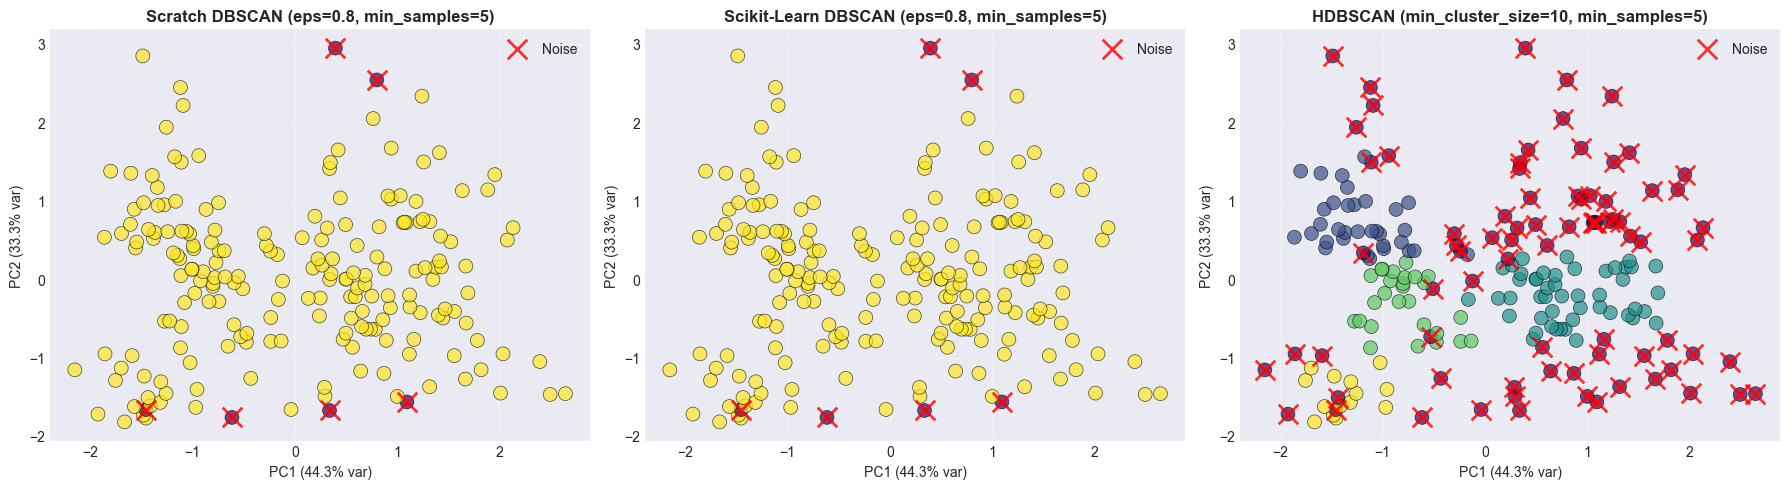

✓ Algorithm comparison saved

2. Noise point analysis...


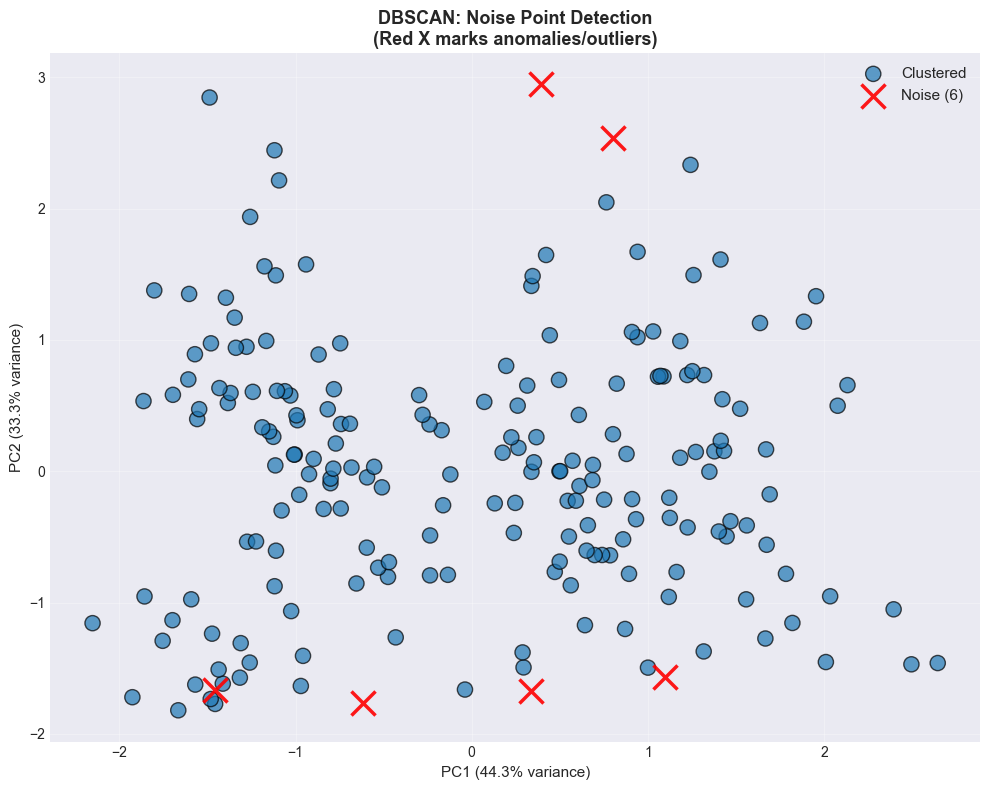

✓ Noise detection plot saved

3. HDBSCAN outlier score visualization...


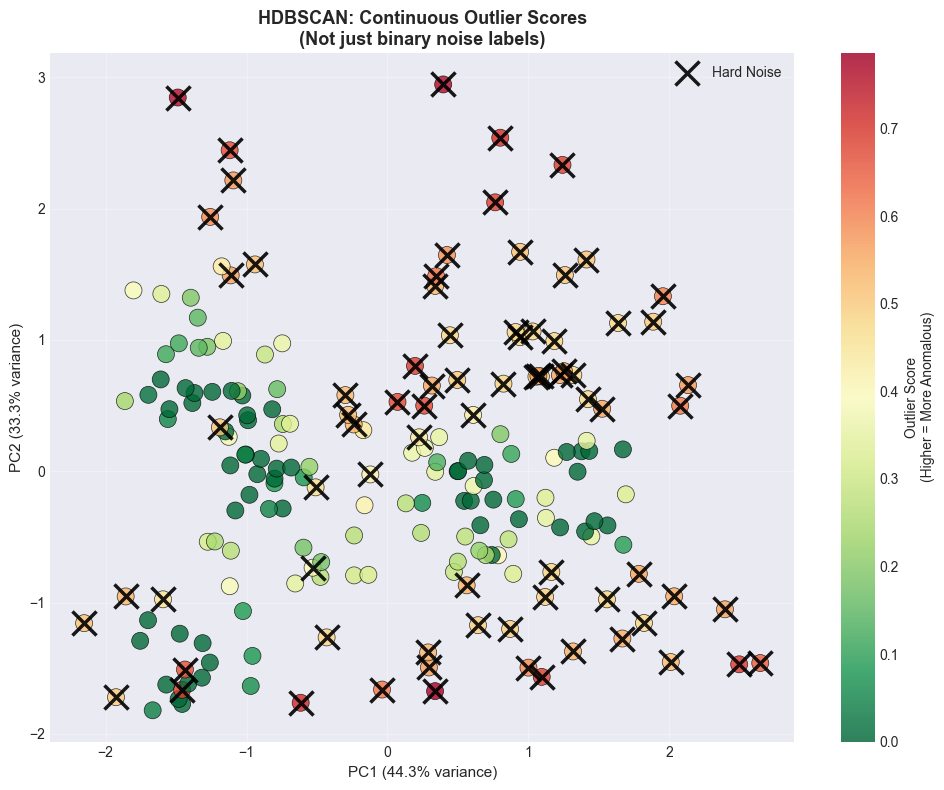

✓ Outlier scores visualization saved

✓ All visualizations complete!


In [7]:
# ============================================================================
# VISUALIZATIONS
# ============================================================================

print("=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

# For 3D data, we'll project to 2D using PCA for visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_processed)

print(f"\nPCA reduction: {X_processed.shape} → {X_pca_2d.shape}")
print(f"Explained variance: {pca_2d.explained_variance_ratio_.sum():.1%}")

# 1. SCRATCH DBSCAN VISUALIZATION
print("\n1. Scratch DBSCAN visualization...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scratch DBSCAN
scatter = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_scratch, 
                         cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
# Highlight noise points
noise_idx = labels_scratch == -1
axes[0].scatter(X_pca_2d[noise_idx, 0], X_pca_2d[noise_idx, 1], 
               c='red', marker='x', s=200, linewidths=2, label='Noise', alpha=0.8)
axes[0].set_title('Scratch DBSCAN (eps=0.8, min_samples=5)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)', fontsize=10)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scikit-Learn DBSCAN
scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_sklearn, 
                         cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
noise_idx_sklearn = labels_sklearn == -1
axes[1].scatter(X_pca_2d[noise_idx_sklearn, 0], X_pca_2d[noise_idx_sklearn, 1], 
               c='red', marker='x', s=200, linewidths=2, label='Noise', alpha=0.8)
axes[1].set_title('Scikit-Learn DBSCAN (eps=0.8, min_samples=5)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)', fontsize=10)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: HDBSCAN
scatter = axes[2].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_hdbscan, 
                         cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=0.5)
noise_idx_hdbscan = labels_hdbscan == -1
axes[2].scatter(X_pca_2d[noise_idx_hdbscan, 0], X_pca_2d[noise_idx_hdbscan, 1], 
               c='red', marker='x', s=200, linewidths=2, label='Noise', alpha=0.8)
axes[2].set_title('HDBSCAN (min_cluster_size=10, min_samples=5)', fontsize=12, fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)', fontsize=10)
axes[2].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)', fontsize=10)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dbscan_hdbscan_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Algorithm comparison saved")

# 2. NOISE POINT HIGHLIGHTING
print("\n2. Noise point analysis...")

fig, ax = plt.subplots(figsize=(10, 8))

# Plot all clustered points
clustered_mask = labels_sklearn != -1
ax.scatter(X_pca_2d[clustered_mask, 0], X_pca_2d[clustered_mask, 1], 
          c=labels_sklearn[clustered_mask], cmap='tab10', s=120, 
          alpha=0.7, edgecolors='black', linewidth=1, label='Clustered')

# Highlight noise points with special marker
noise_mask = labels_sklearn == -1
ax.scatter(X_pca_2d[noise_mask, 0], X_pca_2d[noise_mask, 1], 
          c='red', marker='x', s=300, linewidths=2.5, label=f'Noise ({np.sum(noise_mask)})', 
          alpha=0.9, zorder=5)

ax.set_title('DBSCAN: Noise Point Detection\n(Red X marks anomalies/outliers)', 
            fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('noise_detection.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Noise detection plot saved")

# 3. HDBSCAN OUTLIER SCORES (Continuous scores, not just binary)
print("\n3. HDBSCAN outlier score visualization...")

fig, ax = plt.subplots(figsize=(10, 8))

# Use outlier scores for color intensity
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=outlier_scores, 
                    cmap='RdYlGn_r', s=150, alpha=0.8, edgecolors='black', linewidth=0.5)

# Mark hard noise points (label = -1)
noise_mask_hdbscan = labels_hdbscan == -1
ax.scatter(X_pca_2d[noise_mask_hdbscan, 0], X_pca_2d[noise_mask_hdbscan, 1], 
          marker='x', s=300, linewidths=2.5, c='black', alpha=0.9, label='Hard Noise')

cbar = plt.colorbar(scatter, ax=ax, label='Outlier Score\n(Higher = More Anomalous)')
ax.set_title('HDBSCAN: Continuous Outlier Scores\n(Not just binary noise labels)', 
            fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hdbscan_outlier_scores.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Outlier scores visualization saved")

print(f"\n{'=' * 70}")
print("✓ All visualizations complete!")

---

## Part 4: Hyperparameter Tuning and Sensitivity Analysis

### Key Hyperparameters for DBSCAN and HDBSCAN

**DBSCAN Parameters:**

| Parameter | Effect | Tuning Strategy |
|---|---|---|
| **eps (ε)** | Radius of neighborhoods. **Too small:** all noise. **Too large:** all one cluster | Use k-distance graph: plot sorted distances to k-th nearest neighbor, look for the "elbow" |
| **min_samples (MinPts)** | Minimum neighbors to be core point. **Too small:** noise-sensitive. **Too large:** all noise | Typically 2× dimensionality; often equal to `min_cluster_size` in HDBSCAN |

**HDBSCAN Parameters:**

| Parameter | Effect | Tuning Strategy |
|---|---|---|
| **min_cluster_size** | Minimum cluster size (larger = more conservative). Directly filters hierarchy | Start with 10-20, increase if over-fragmenting |
| **min_samples** | Density threshold (default = `min_cluster_size`). Controls noise sensitivity | Higher = more permissive to noise; affects stability scores |

### Common Mistakes

1. **Forgetting to scale features:** Different feature scales make ε meaningless
2. **Choosing ε without data inspection:** Use k-distance graphs to estimate reasonable range
3. **Too many noise points:** Usually means ε too small
4. **Too many tiny clusters:** min_samples too small or data naturally fragmented
5. **Using DBSCAN with varying density:** Switch to HDBSCAN instead

EXPERIMENT 1: VARYING EPS PARAMETER (DBSCAN)
  eps=0.4 → clusters= 6, noise= 98 ( 49.0%), silhouette= 0.5190
  eps=0.6 → clusters= 2, noise= 28 ( 14.0%), silhouette= 0.2730
  eps=0.8 → clusters= 1, noise=  6 (  3.0%), silhouette=    nan
  eps=1.0 → clusters= 1, noise=  2 (  1.0%), silhouette=    nan
  eps=1.2 → clusters= 1, noise=  0 (  0.0%), silhouette=    nan
  eps=1.5 → clusters= 1, noise=  0 (  0.0%), silhouette=    nan


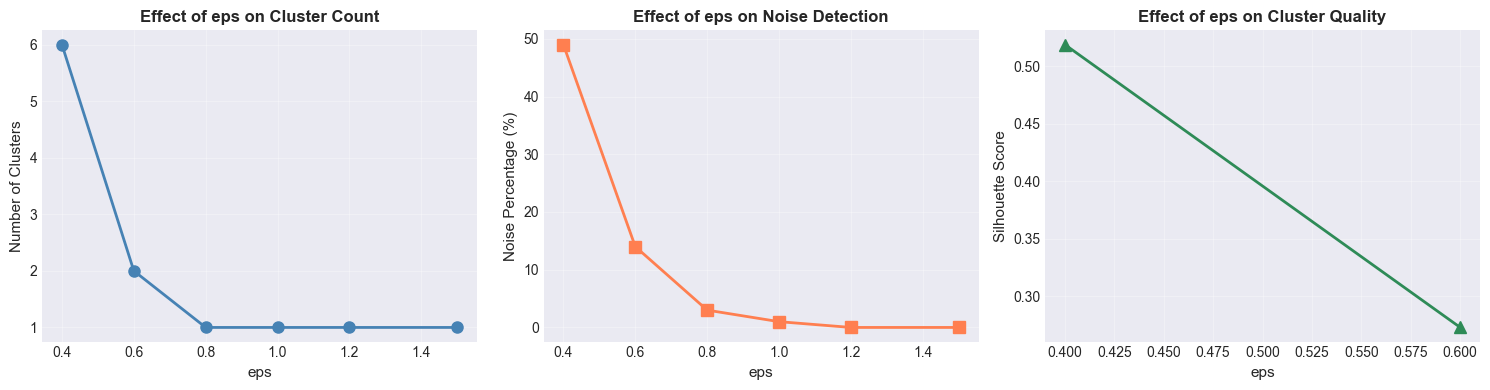

✓ eps tuning visualization saved

EXPERIMENT 2: HDBSCAN MIN_CLUSTER_SIZE SENSITIVITY
  min_size= 5 → clusters= 5, noise= 69 ( 34.5%), silhouette= 0.5315
  min_size=10 → clusters= 4, noise= 78 ( 39.0%), silhouette= 0.5429
  min_size=15 → clusters= 3, noise= 77 ( 38.5%), silhouette= 0.5232
  min_size=20 → clusters= 3, noise= 77 ( 38.5%), silhouette= 0.5232
  min_size=30 → clusters= 2, noise= 53 ( 26.5%), silhouette= 0.2816


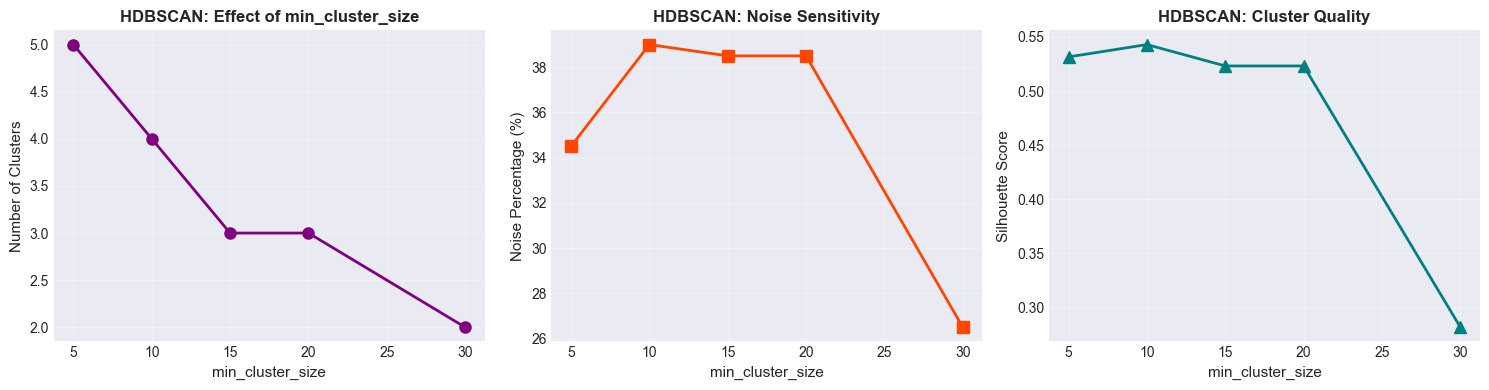

✓ HDBSCAN tuning visualization saved

✓ Hyperparameter experiments complete!


In [8]:
# ============================================================================
# HYPERPARAMETER TUNING EXPERIMENTS
# ============================================================================

print("=" * 70)
print("EXPERIMENT 1: VARYING EPS PARAMETER (DBSCAN)")
print("=" * 70)

eps_values = [0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
results_eps = []

for eps_val in eps_values:
    model = DBSCAN(eps=eps_val, min_samples=5, algorithm='ball_tree')
    labels = model.fit_predict(X_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_pct = 100 * n_noise / len(labels)
    
    # Compute metrics if we have valid clusters
    if n_clusters > 0 and n_noise < len(labels) - 1:
        non_noise = labels != -1
        if np.sum(non_noise) > 1 and len(set(labels[non_noise])) > 1:
            sil = silhouette_score(X_processed[non_noise], labels[non_noise])
        else:
            sil = np.nan
    else:
        sil = np.nan
    
    results_eps.append({
        'eps': eps_val,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct,
        'silhouette': sil
    })
    
    print(f"  eps={eps_val:3.1f} → clusters={n_clusters:2d}, noise={n_noise:3d} ({noise_pct:5.1f}%), silhouette={sil:7.4f}")

df_eps = pd.DataFrame(results_eps)

# Visualize eps impact
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_eps['eps'], df_eps['n_clusters'], marker='o', linewidth=2, markersize=8, color='steelblue')
axes[0].set_xlabel('eps', fontsize=11)
axes[0].set_ylabel('Number of Clusters', fontsize=11)
axes[0].set_title('Effect of eps on Cluster Count', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_eps['eps'], df_eps['noise_pct'], marker='s', linewidth=2, markersize=8, color='coral')
axes[1].set_xlabel('eps', fontsize=11)
axes[1].set_ylabel('Noise Percentage (%)', fontsize=11)
axes[1].set_title('Effect of eps on Noise Detection', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_eps['eps'], df_eps['silhouette'], marker='^', linewidth=2, markersize=8, color='seagreen')
axes[2].set_xlabel('eps', fontsize=11)
axes[2].set_ylabel('Silhouette Score', fontsize=11)
axes[2].set_title('Effect of eps on Cluster Quality', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eps_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ eps tuning visualization saved")

# ============================================================================
print(f"\n{'=' * 70}")
print("EXPERIMENT 2: HDBSCAN MIN_CLUSTER_SIZE SENSITIVITY")
print("=" * 70)

min_cluster_sizes = [5, 10, 15, 20, 30]
results_hdbscan_size = []

for min_size in min_cluster_sizes:
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_size, min_samples=5, 
                               cluster_selection_method='eom', prediction_data=True)
    labels = clusterer.fit_predict(X_processed)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    noise_pct = 100 * n_noise / len(labels)
    
    # Compute metrics
    if n_clusters > 0 and n_noise < len(labels) - 1:
        non_noise = labels != -1
        if np.sum(non_noise) > 1 and len(set(labels[non_noise])) > 1:
            sil = silhouette_score(X_processed[non_noise], labels[non_noise])
        else:
            sil = np.nan
    else:
        sil = np.nan
    
    results_hdbscan_size.append({
        'min_cluster_size': min_size,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct,
        'silhouette': sil
    })
    
    print(f"  min_size={min_size:2d} → clusters={n_clusters:2d}, noise={n_noise:3d} ({noise_pct:5.1f}%), silhouette={sil:7.4f}")

df_hdbscan_size = pd.DataFrame(results_hdbscan_size)

# Visualize min_cluster_size impact
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_hdbscan_size['min_cluster_size'], df_hdbscan_size['n_clusters'], 
            marker='o', linewidth=2, markersize=8, color='purple')
axes[0].set_xlabel('min_cluster_size', fontsize=11)
axes[0].set_ylabel('Number of Clusters', fontsize=11)
axes[0].set_title('HDBSCAN: Effect of min_cluster_size', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_hdbscan_size['min_cluster_size'], df_hdbscan_size['noise_pct'], 
            marker='s', linewidth=2, markersize=8, color='orangered')
axes[1].set_xlabel('min_cluster_size', fontsize=11)
axes[1].set_ylabel('Noise Percentage (%)', fontsize=11)
axes[1].set_title('HDBSCAN: Noise Sensitivity', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df_hdbscan_size['min_cluster_size'], df_hdbscan_size['silhouette'], 
            marker='^', linewidth=2, markersize=8, color='teal')
axes[2].set_xlabel('min_cluster_size', fontsize=11)
axes[2].set_ylabel('Silhouette Score', fontsize=11)
axes[2].set_title('HDBSCAN: Cluster Quality', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hdbscan_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ HDBSCAN tuning visualization saved")

print(f"\n{'=' * 70}")
print("✓ Hyperparameter experiments complete!")

---

## Part 5: Interview Corner — FAANG-Style Questions & Answers

### Question 1: Why Doesn't DBSCAN Require Specifying k Like K-Means Does?

**Answer:**
DBSCAN discovers clusters as an emergent property of density-based connectivity rather than assigning points to k pre-defined centroids. The algorithm asks: "Which points form connected regions of sufficient density?" rather than "Which of k buckets does this belong to?" The number of clusters is determined by how many separate connected components form under the density criteria (ε and MinPts).

**Key Insight:** Increasing ε merges clusters together; decreasing ε splits them or creates noise. This flexibility—discovering k automatically—is DBSCAN's core advantage. However, you still need to tune two parameters (ε and MinPts), which is a different challenge than choosing k.

**Interview Follow-Up:** "How do you choose ε?" → Use k-distance graph: plot sorted distances to the k-th nearest neighbor, look for the "elbow"—the distance where a sharp increase occurs is a good ε candidate.

---

### Question 2: Explain Core Points, Border Points, and Noise Points

**Answer:**

| Point Type | Definition | Cluster Assignment |
|---|---|---|
| **Core Point** | ≥ MinPts neighbors within ε (including self) | Always assigned to a cluster |
| **Border Point** | <MinPts neighbors but within ε of a core point | Assigned to core point's cluster (first-come-first-served if reachable from multiple cores) |
| **Noise Point** | Neither core nor border | Labeled -1 (outlier/anomaly) |

**Real-World Analogy:** Think of a city planning meeting where "core points" are central downtown blocks with many nearby buildings (dense). "Border points" are residential areas adjacent to downtown. "Noise points" are isolated rural villages far from any dense region.

**Interview Nuance:** This taxonomy reveals why DBSCAN has built-in outlier detection (unlike K-Means)—it's not forced to assign every point; some remain unassigned as noise.

---

### Question 3: What is the Role of eps (ε)?

**Answer:**
ε defines the radius of the neighborhood search. All points within Euclidean distance ≤ ε of a given point are considered neighbors (ε-neighborhood). This parameter controls the scale at which density is measured.

**Impact:**
- **Too small ε:** Most points are noise; clusters fragment or disappear
- **Too large ε:** Everything merges into one cluster; no meaningful structure
- **Optimal ε:** Clusters naturally emerge with reasonable noise levels

**Choosing ε (Practical Method - k-Distance Graph):**
```
1. Compute distance to k-th nearest neighbor for all points (k = MinPts)
2. Sort these distances in descending order
3. Plot as curve
4. Find the "elbow"—sharp increase in distance
5. Use that distance as ε
```

**Common Mistake:** Using a fixed ε for datasets with varying densities (HDBSCAN solves this).

---

### Question 4: Why Does DBSCAN Struggle with Varying Cluster Densities?

**Answer:**
DBSCAN uses a single global ε for all neighborhoods. In real-world data, clusters often have different internal densities:
- A dense downtown cluster and a sparse suburban cluster can't both be captured by one ε
- If ε is chosen for the sparse cluster, the dense cluster works fine
- If ε is chosen for the dense cluster, the sparse cluster becomes all noise

**Example:** Customer spending patterns: high-frequency buyers (dense) vs. occasional buyers (sparse). One ε can't capture both well.

**HDBSCAN Solution:** Builds a hierarchy across all possible ε values simultaneously, then automatically selects clusters that remain "stable" across many density levels. This elegantly handles multi-scale densities.

---

### Question 5: How Does HDBSCAN Solve DBSCAN Limitations?

**Answer:**
HDBSCAN addresses three key limitations:

1. **Varying Densities:** Uses mutual reachability distance (adapts to local density) instead of global ε
2. **Parameter Tuning:** Eliminates ε; only requires `min_cluster_size` (less sensitive)
3. **Soft Membership:** Provides outlier scores (0-1) and membership probabilities, not just binary labels

**Key Insight:** HDBSCAN builds a **condensed cluster tree** across all density levels, then selects clusters with the highest "stability" scores. Stability = how long a cluster persists across density thresholds. Stable clusters are robust; unstable ones (appear/disappear quickly) are discarded.

**When to Use Each:**
- **DBSCAN:** Small data, known ε from domain knowledge, homogeneous cluster densities
- **HDBSCAN:** Large data, unknown density structure, varying cluster densities, need outlier scores

---

### Question 6: Design an Anomaly Detection Pipeline Using HDBSCAN

**Answer - Step-by-Step:**

1. **Data Preparation:**
   - Load features (scale with StandardScaler)
   - If high-dimensional (>50 features), reduce to 10-20 dimensions using UMAP (density-preserving) or PCA

2. **HDBSCAN Clustering:**
   ```python
   clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
   labels = clusterer.fit_predict(X_scaled)
   outlier_scores = clusterer.outlier_scores_
   ```

3. **Anomaly Identification:**
   - Hard anomalies: label = -1 (noise points)
   - Soft anomalies: high outlier_scores (0-1 continuous scores)

4. **Tuning:**
   - Increase `min_cluster_size` if too many noise points
   - Adjust to match business expectations (e.g., "top 5% anomalies")

5. **Evaluation:**
   - If ground-truth labels available: precision/recall on known anomalies
   - If no labels: visual inspection + domain expert validation

**Interview Advantage:** This pipeline shows understanding of practical ML: preprocessing, dimensionality reduction, density-based reasoning, and validation without labels.

---

### Common Mistakes Candidates Make

1. **Not scaling features:** DBSCAN/HDBSCAN are distance-based; different feature scales break everything
2. **Assuming DBSCAN always works:** It fails on varying-density data (use HDBSCAN instead)
3. **Forgetting noise points exist:** DBSCAN produces noise; don't treat it like K-Means
4. **Choosing ε without inspection:** Always use k-distance graphs or domain knowledge, not guessing
5. **High-dimensional curse:** Distances become meaningless in very high dimensions (>50-100); reduce first



---

## Key Takeaways

### 5 Essential Concepts to Remember

1. **Density-Based vs. Distance-Based Clustering**
   - DBSCAN/HDBSCAN group points in dense neighborhoods (not distance to centroids like K-Means)
   - Naturally detect outliers (noise points)
   - No need to specify k, but ε/MinPts must be tuned instead

2. **Understanding the Core/Border/Noise Taxonomy**
   - Core points (≥MinPts neighbors) form cluster seeds
   - Border points (neighbors of core) attach to clusters
   - Noise points remain unassigned, making DBSCAN a true outlier detector
   - This flexibility is DBSCAN's killer feature

3. **Implementation Complexity Trade-Offs**
   - Naive DBSCAN: O(n²) without spatial indexing—still practical for <100k points
   - Library DBSCAN: O(n log n) with KD-tree/Ball-tree (use this in production)
   - From-scratch implementation: invaluable for interviews, debugging, and understanding

4. **Hyperparameter Tuning and Data Preparation**
   - **Always scale features first** (StandardScaler)—distances are meaningless without it
   - Choose ε using k-distance graphs (plot distance to k-th nearest neighbor, find elbow)
   - DBSCAN struggles with varying densities → switch to HDBSCAN
   - HDBSCAN eliminates ε; only tune `min_cluster_size` (more forgiving)

5. **Interview-Critical Insights**
   - DBSCAN = graph connectivity algorithm (clusters are connected components)
   - HDBSCAN = hierarchy + stability scores (automatic density adaptation)
   - Curse of dimensionality: distances become meaningless in high dimensions (>50-100 features)
   - Outlier detection for free: noise points are genuine anomalies, not forced-fit clusters

---

### Quick Reference Cheat Sheet

| Aspect | DBSCAN | HDBSCAN |
|---|---|---|
| **Requires k?** | No | No |
| **Density-varying data?** | ❌ Struggles | ✅ Handles well |
| **Time Complexity** | O(n log n) with spatial index | O(n log n) |
| **Outlier Detection?** | ✅ Binary (noise/non-noise) | ✅ Continuous scores |
| **Parameters to Tune** | ε, MinPts (harder) | min_cluster_size, min_samples (easier) |
| **Production Use** | Yes (if density homogeneous) | Yes (recommended for unknown data) |
| **Interview Favorite?** | ✅ Yes (simpler concepts) | ✅✅ Yes (advanced features) |

---

### Final Code Snippets for Interview Prep

**When to use DBSCAN:**
```python
from sklearn.cluster import DBSCAN
# Known ε from domain expertise, homogeneous densities
clustering = DBSCAN(eps=0.8, min_samples=5).fit(X_scaled)
```

**When to use HDBSCAN:**
```python
import hdbscan
# Unknown data structure, varying densities, need outlier scores
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=5)
labels = clusterer.fit_predict(X_scaled)
outlier_scores = clusterer.outlier_scores_
```

**Anomaly Detection:**
```python
# Any points with label == -1 are anomalies
anomalies = X_scaled[labels == -1]
anomaly_scores = clusterer.outlier_scores_[labels == -1]
```

---

### Recommended Reading/Resources

- **Original DBSCAN Paper:** Ester et al., "A Density-Based Algorithm for Discovering Clusters" (1996)
- **HDBSCAN Paper:** Campello et al., "Hierarchical Density Estimates for Data Clustering..." (2013)
- **k-Distance Graphs:** Essential for ε selection—always plot before running DBSCAN
- **Curse of Dimensionality:** Why distances fail in high-d spaces; PCA/UMAP before clustering
- **Outlier Score Interpretation:** HDBSCAN outlier_scores_ ∈ [0, 1]; higher = more anomalous

---

**Congratulations!** You now have production-grade DBSCAN and HDBSCAN implementations, understanding both from-scratch algorithms and optimized libraries, complete with practical hyperparameter tuning and interview preparation. Use this knowledge to impress in technical interviews and build robust clustering pipelines!